# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 15000 entries, 0 to 14999
,Data columns (total 12 columns):
, #   Column                     Non-Null Count  Dtype  
,---  ------                     --------------  -----  
, 0   id_cliente                 15000 non-null  object 
, 1   edad                       15000 non-null  float64
, 2   nivel_ingreso              15000 non-null  float64
, 3   visitas_mes                15000 non-null  int64  
, 4   compras_mes                15000 non-null  int64  
, 5   gasto_publicidad_dirigida  15000 non-null  float64
, 6   satisfaccion               15000 non-null  float64
, 7   miembro_premium            15000 non-null  int64  
, 8   abandono                   15000 non-null  int64  
, 9   tipo_dispositivo           15000 non-null  object 
, 10  region                     15000 non-null  object 
, 11  ingreso_anual              15000 non-null  float64
,dtypes: float64(5), int64(4), object(3)
,memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [4]:
# mostrar las primeras 5 filas
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:   
- `edad`       
- `nivel_ingreso`    
- `visitas_mes`   
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `edad` es un tipo de dato float, se realiza cambio pra ser int.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [5]:
# Corregir el tipo de dato
df['edad']= df['edad'].astype('int')

In [6]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 15000 entries, 0 to 14999
,Data columns (total 12 columns):
, #   Column                     Non-Null Count  Dtype  
,---  ------                     --------------  -----  
, 0   id_cliente                 15000 non-null  object 
, 1   edad                       15000 non-null  int64  
, 2   nivel_ingreso              15000 non-null  float64
, 3   visitas_mes                15000 non-null  int64  
, 4   compras_mes                15000 non-null  int64  
, 5   gasto_publicidad_dirigida  15000 non-null  float64
, 6   satisfaccion               15000 non-null  float64
, 7   miembro_premium            15000 non-null  int64  
, 8   abandono                   15000 non-null  int64  
, 9   tipo_dispositivo           15000 non-null  object 
, 10  region                     15000 non-null  object 
, 11  ingreso_anual              15000 non-null  float64
,dtypes: float64(4), int64(5), object(3)
,memory usage: 1.4+ MB


#### Explorar variables numéricas

In [7]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas=['edad', 'nivel_ingreso',
                    'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida',
                    'satisfaccion' , 'ingreso_anual']  
df[columnas_numericas].describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


**Diagnóstico inicial de variables numéricas**

- `edad` — rango completo (18-75), distribucion centrada (38).      
- `nivel_ingreso` — posibles outliers con un sesgo a la derecha y alta dispersion.       
- `visitas_mes` — rango chico (1-25), con una distribucion moderada.   
- `compras_mes` — valores en 0, baja media (1.2) lo que puede indicar baja frecuencia de compra general.
- `gasto_publicidad_dirigida` — valores en 0, con un sesgo a la derecha.   
- `satisfaccion` — Variable discreta (1-5), meadia y mediana cercanos a 3.6 (satisfaccion media-alta).  
- `ingreso_anual` — valores en 0, sesgo a la derecha, posibles outliers.

#### Explorar variables binarias

In [21]:
# Verificar que cada columna tenga únicamente dos valores posibles
print(df['miembro_premium'].value_counts(normalize=True))
print(df['abandono'].value_counts(normalize=True))

0    0.860733
,1    0.139267
,Name: miembro_premium, dtype: float64
,0    0.849267
,1    0.150733
,Name: abandono, dtype: float64


✍️ **Diagnóstico inicial de variables binarias**

- `miembro_premium` — Verificacion de contar con solo dos variables siendo solo un 13% los suscriptos a un plan premium.    
- `abandono` — Verificacion de contar con solo dos variables contando con un 85% aunactivos en plataforma.

#### Explorar variables categóricas

In [24]:
# Verificar el número de valores únicos por variable categórica
df[['tipo_dispositivo', 'region']].nunique()

tipo_dispositivo    3
region              4
dtype: int64

In [25]:
# Explorar variables categóricas y cómo se distribuyen
df[['tipo_dispositivo', 'region']].describe()

,tipo_dispositivo,region
count,15000,15000
unique,3,4
top,móvil,norte
freq,9818,4395


✍️ **Diagnóstico inicial de variables categóricas**

- `tipo_dispositivo` — 3 diferentes dispositivos, siendo el 'movil' el mas frequente (65%).
- `region` — 4 regiones siendo norte el mas pupolar (29%)

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

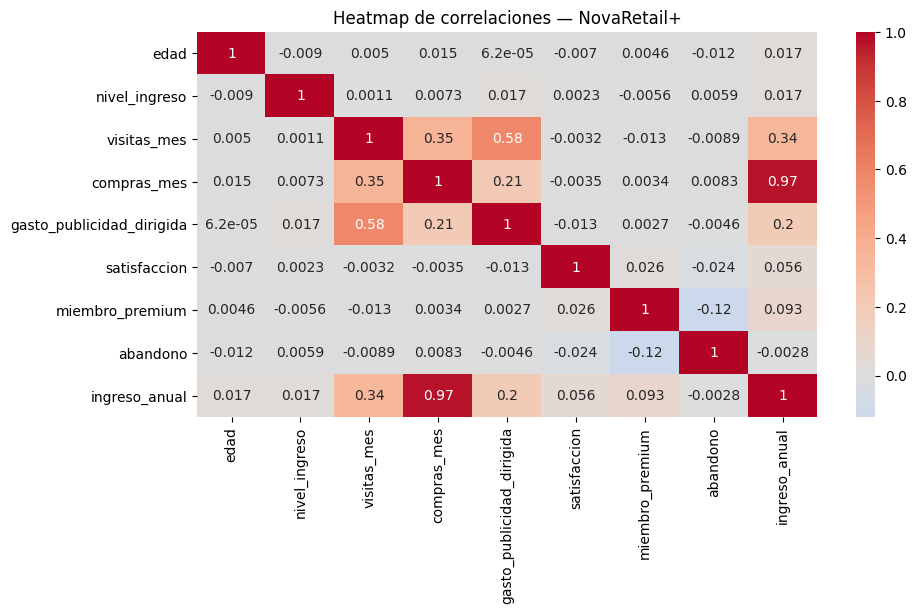

In [4]:
# Visualizar la matriz de correlación para identificar relaciones
corr=df.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Heatmap de correlaciones — NovaRetail+")
plt.show()

✍️ **Observaciones generales (Heatmap)**  

  Correlaciones mas destacadas:    
- `Gasto_publicidad` vs `visitas_mes`: Alta-positiva (0.58).
- `Compras_mes` vs `visitas_mes`: Alta-positiva (0.35).
- `Gasto_publicidad` vs `compras_mes`: Alta-positiva (0.21).

El resto de los valores estan muy cercanos a cero lo que nos indica que no existe una correlacion.

Observaciones respecto a `ingreso_anual`  
 Presenta 3 altos-positivos: 
- `Gasto_publicidad` (0.2), sin embargo esta sigue siendo muy baja.  
- `Visitas_mes` (0.34)
- `Compras_mes` (0.97), siendo la correlacion mas fuerte sin asumir ninguna causalidad.


### Scatterplot general

Con base en los resultados del análisis de correlación, se evaluo que no es necesario generar un *scatterplot* general ya que de 12 columnas solo 4 arrojan datos de una posible correlacion. El resto de los valores es muy cercaco a 0, casi nula. Y sobre todo porque nuestro objetivo esta dirigido a la asociasion con `ingreso_anual`.

### Scatterplot para pares clave

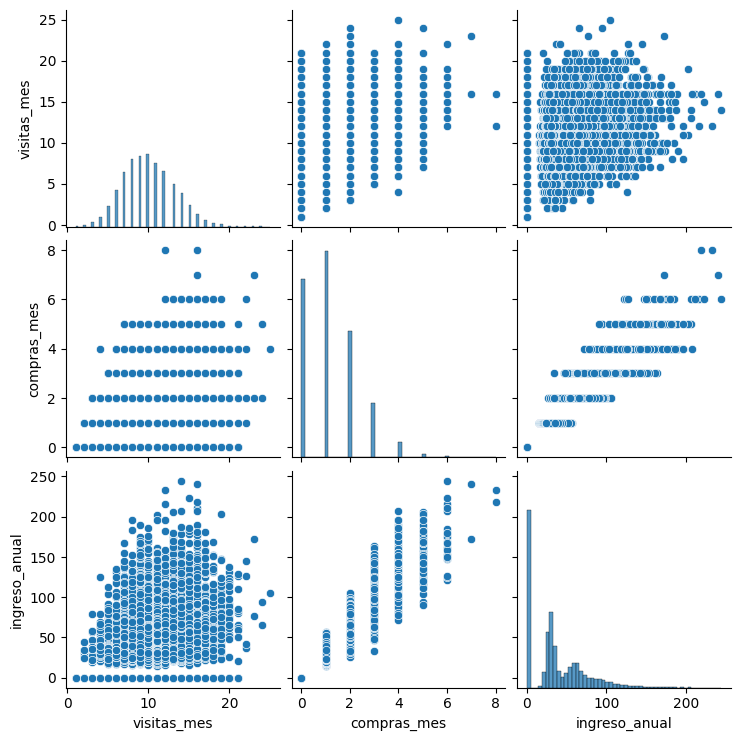

In [5]:
# Visualizar pares de variables con relaciones moderadas o fuertes
sns.pairplot(df[['visitas_mes', 'compras_mes', 'ingreso_anual']])
plt.show()

✍️ **Observaciones iniciales (Scatterplot)**

**`Visitas_mes` vs `Compras_mes`**   
- Dirección positiva.
- Dispersion media.
- Presencia de outliers.

**`Compras_mes` vs `ingreso_anual`**    
- Dirección positiva.
- Dispersion baja.
- Presencia minima de utliers.
- Posible colinealidad.

**`Visitas_mes` vs `ingreso_anual`**  
- Dirección positiva.
- Dispersion alta.
- Presencia de utliers.
 

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [9]:
def corr_numerica(df, columnas, metodo="pearson"):
    matriz = df[columnas].corr(method=metodo)
    return matriz.style.background_gradient(cmap="coolwarm")

In [17]:
columnas_numericas=['visitas_mes', 'compras_mes', 'ingreso_anual']
corr_numerica(df, columnas_numericas, metodo="pearson")

,visitas_mes,compras_mes,ingreso_anual
visitas_mes,1.000000,0.353844,0.337147
compras_mes,0.353844,1.000000,0.967149
ingreso_anual,0.337147,0.967149,1.000000


In [13]:
corr_numerica(df, columnas_numericas, metodo="spearman")

,visitas_mes,compras_mes,ingreso_anual
visitas_mes,1.000000,0.332943,0.320954
compras_mes,0.332943,1.000000,0.967482
ingreso_anual,0.320954,0.967482,1.000000


✍️ **Observaciones**

**Pearson vs Spearman**
Ambas matrices muestran resultados muy similares, lo que indica que las relaciones son consistentes y no dependen fuertemente de outliers.

**1. compras_mes ↔ ingreso_anual (0.967)**  
Correlación muy fuerte y positiva  
Es la relación más importante del análisis  
⚠️ Posible colinealidad: si ambas variables se usan como predictores en un modelo, pueden generar problemas de multicolinealidad  

**2. visitas_mes ↔ compras_mes (0.35)**   
Correlación positiva débil/moderada  

**3. visitas_mes ↔ ingreso_anual (0.33)**   
Correlación positiva débil  
 

### Punto-biserial

In [21]:
# Calcular correlación entre variables relevantes
from scipy.stats import pointbiserialr

pb,_ = pointbiserialr(df["miembro_premium"],df["ingreso_anual"])
print(f"Punto-biserial: {pb:.3f}")

Punto-biserial: 0.093


In [22]:
pb,_ = pointbiserialr(df["abandono"],df["ingreso_anual"])
print(f"Punto-biserial: {pb:.3f}")

Punto-biserial: -0.003


✍️ **Observaciones Punto-biserial**

Se realiza diagnostico de Punto biserial solo para confirmar los datos que arrojo el heatmap, y como se observa solo se confirmo una vez mas que no hay ninguna correlacion con estas dos variables.

### V de Cramér

In [4]:
# Función para calcular V de Cramér
import numpy as np
from scipy.stats import chi2_contingency

def cramer_v(df, col1, col2):
    tabla = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(tabla)
    n = tabla.values.sum()
    v = np.sqrt(chi2 / (n * (min(tabla.shape) -1)))
    return v

In [5]:
# Aplicar V de Cramér en variables relevantes
coef_cramer = cramer_v(df, "region", "tipo_dispositivo")

print("\nCorrelación entre: region y tipo dispositivo")
print(f"V de Cramér: {coef_cramer :.3f}")


,Correlación entre: region y tipo dispositivo
,V de Cramér: 0.012


✍️ **Observaciones V de Cramér**  
Recordemos que utilizamos V de Cramér solo para ver la correlacion entre variables categoricas, este caso solo contamos con dos `region` y `tipo_dispositivo` las cuales indican no tener ninguna correlacion.

## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1 — 
**Compras_mes es la variable más fuertemente asociada con ingreso_anual**    
**Evidencia visual:**   
Scatterplot compras_mes vs ingreso_anual — tendencia lineal muy ajustada, dispersión baja, pocos outliers. Confirmado en pairplot y heatmap (celda en rojo intenso).   
**Evidencia numérica:**   
Pearson r = 0.967 / Spearman ρ = 0.967   
**Interpretación**  
Los clientes con mayor frecuencia de compra mensual tienden a estar asociados con mayores ingresos anuales para la plataforma. La relación es positiva, casi perfecta, y consistente en ambos métodos, lo que sugiere que es robusta frente a valores atípicos y no depende de supuestos de linealidad.   
**No podemos afirmar**    
Que incrementar las compras cause directamente un aumento en el ingreso anual. Variables no observadas —como el tipo de productos comprados, el valor promedio por transacción o el perfil socioeconómico del cliente— podrían estar explicando parte de esta asociación.
**Implicación de negocio**   
compras_mes parece ser el indicador de comportamiento más alineado con el valor económico del cliente. Se propone la hipótesis de que estrategias orientadas a aumentar la frecuencia de compra (incentivos de recompra, ofertas personalizadas, recordatorios) podrían estar asociadas con mayor ingreso. Requiere validación experimental.
⚠️ Por su nivel de colinealidad (r = 0.967), no se recomienda usar compras_mes e ingreso_anual como variables independientes simultáneas en modelos predictivos futuros.

### Hallazgo 2 — 

**Gasto_publicidad_dirigida está moderadamente asociado con visitas_mes, pero no directamente con ingreso_anual**   
**Evidencia visual:**  
Heatmap — celda gasto_publicidad_dirigida × visitas_mes en naranja (≈ 0.58); celda gasto_publicidad_dirigida × ingreso_anual cercana a neutro (≈ 0.20).   
**Evidencia numérica:**   
Pearson r ≈ 0.58 (publicidad ↔ visitas) / Pearson r ≈ 0.20 (publicidad ↔ ingreso)   
**Interpretación**   
A mayor gasto en publicidad dirigida, se observa mayor cantidad de visitas mensuales. Sin embargo, ese aumento en visitas no se traduce de forma directa ni proporcional en mayor ingreso anual — la correlación publicidad–ingreso es débil. Esto podría sugerir que las visitas generadas por publicidad no siempre terminan en compra.    
**No podemos afirmar**   
Que la publicidad produce visitas, ni que las visitas generen ingresos. El gasto publicitario podría estar siendo asignado a usuarios ya activos (sesgo de selección), y las visitas podrían ser de exploración sin intención de compra.   
**Implicación de negocio**   
Se propone la hipótesis de que existe una cadena parcial publicidad → visitas → compras → ingreso, donde el eslabón débil es la conversión de visitas a compras. Explorar la tasa de conversión como métrica intermedia podría ser un próximo paso relevante para evaluar la eficiencia de la inversión publicitaria. 


### Hallazgo 3 —   
**miembro_premium y abandono no muestran asociación con ingreso_anual a nivel agregado**   
**Evidencia visual:**   
Heatmap — celdas correspondientes a miembro_premium y abandono con valores cercanos a 0 (color blanco/neutro).   
**Evidencia numérica:**   
Punto-biserial ≈ 0.00 para ambas variables (no significativo)   
**Interpretación**   
Ni el estatus de membresía premium (solo el 13% de usuarios) ni el abandono de la plataforma (~15%) presentan asociación estadística apreciable con el ingreso anual cuando se analiza la base completa. A nivel global, ser premium o haber abandonado no distingue perfiles de mayor o menor ingreso.   
**No podemos afirmar**   
Que la membresía premium sea irrelevante para el negocio. La ausencia de correlación global puede ocultar efectos importantes dentro de subgrupos — por ejemplo, clientes premium con alta frecuencia de compra podrían concentrar una porción desproporcionada del ingreso total.   
**Implicación de negocio**       
Estas variables podrían ser más útiles como criterios de segmentación que como predictores directos de ingreso. Se propone realizar un análisis estratificado: calcular las correlaciones de las secciones anteriores de forma separada para clientes premium vs. no premium, y para clientes activos vs. que abandonaron, para detectar patrones que el análisis agregado no captura.   

## Sección 6 - Limitaciones y próximos pasos

### **Limitaciones**
- **Correlación ≠ causalidad.**
Ningún hallazgo de este reporte establece que una variable *provoque* cambios en otra. Las asociaciones observadas son punto de partida para formular hipótesis, no para tomar decisiones operativas definitivas.   
- **Variables no medidas.**
El dataset no incluye información sobre valor promedio por transacción, categoría de productos comprados, antigüedad del cliente ni historial de precios. Estas variables podrían explicar parte de la varianza en `ingreso_anual` que las variables actuales no capturan.   
- **Análisis agregado.**
Las correlaciones se calcularon sobre toda la base sin distinción de segmentos. Patrones relevantes dentro de subgrupos (premium vs. no premium, por región o dispositivo) podrían quedar invisibles al nivel global.   
- **Colinealidad severa.**
La correlación de 0.967 entre `compras_mes` e `ingreso_anual` limita el uso simultáneo de ambas variables en modelos predictivos futuros y podría estar inflando artificialmente la importancia aparente de `compras_mes`.   
- **Posibles relaciones no lineales no detectadas.**
Pearson y Spearman son sensibles a relaciones monótonas. Variables como `satisfaccion` o `edad` podrían tener efectos de umbral o de U-invertida con `ingreso_anual` que estos métodos no capturan.   
- **Corte temporal único.**
El dataset representa un momento en el tiempo. No es posible evaluar si las asociaciones observadas son estables, estacionales o producto de un período atípico.   

### **Próximos pasos** 

- **Análisis segmentado.** Calcular las correlaciones principales de forma separada para clientes premium vs. no premium, por región geográfica y por tipo de dispositivo. Esto permitiría detectar si la fuerza o dirección de las relaciones varía entre subgrupos.
- **Análisis de conversión.** Explorar la tasa de conversión visitas → compras como métrica intermedia. Evaluar si los usuarios captados vía publicidad dirigida convierten a tasas distintas que el resto.
- **Detección de no-linealidades.** Aplicar correlación de distancias (*distance correlation*) o mutual information para evaluar si `satisfaccion`, `edad` y `nivel_ingreso` tienen relaciones con `ingreso_anual` que los métodos lineales no detectaron.
- **Análisis de mediación.** Evaluar formalmente si `visitas_mes` actúa como mediador en la cadena `gasto_publicidad → visitas → compras → ingreso`, usando técnicas de análisis de rutas (*path analysis*).
- **Experimento controlado.** Diseñar un A/B test sobre campañas de publicidad dirigida para determinar si el aumento en visitas observado en este análisis tiene componente causal, o si responde a sesgo de asignación.
- **Análisis temporal.** Incorporar datos históricos para evaluar si las correlaciones son estables en el tiempo o varían por temporada, lo que permitiría distinguir comportamientos estructurales de efectos coyunturales.
